#### Step1: ایجاد داده 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf , plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from arch import arch_model

##### شبیه سازی داده خام قیمت (500 روز کاری) 

In [2]:
np.random.seed(42)
dates = pd.date_range(start="2025-01-01", periods=500, freq="B")

##### ساخت مسیر قیمت غیر ایستا(Random Wolk)

In [3]:
price_path = 1000 * np.exp(np.cumsum(np.random.normal(0.0005,0.02,500)))
df= pd.DataFrame({'price': price_path} , index=dates)

#### Step2: داده خام قیمت و مسئله ایستایی/مانایی (Stationarity)

##### تبدیل قیمت غیرایستا به بازدهی لوگاریتمی ایستا

In [4]:
df['log_return'] = np.log(df['price'] / df['price'].shift(1))
returns = df['log_return'].dropna() * 100

##### تابع اجرای آزمون ADF (Augmented Dickey-Fuller)

In [5]:
def check_stationarity(series, name):
    result = adfuller(series)
    print(f"--- آزمون ایستایی (ADF) برای {name} ---")
    print(f"آماره آزمون (Test Statistic): {result[0]:.4f}")
    print(f"p-value: {result[1]:.4f}")
    if result[1] < 0.05:
        print("نتیجه: داده ایستا/مانا است (p-value < 0.05).\n")
    else:
        print("نتیجه: داده غیرایستا است (p-value >= 0.05).\n")

##### بررسی ایستایی قیمت خام در مقایسه با بازدهی

In [6]:
check_stationarity(df['price'], "قیمت خام")
check_stationarity(returns, "بازدهی لوگاریتمی")

--- آزمون ایستایی (ADF) برای قیمت خام ---
آماره آزمون (Test Statistic): -0.9099
p-value: 0.7847
نتیجه: داده غیرایستا است (p-value >= 0.05).

--- آزمون ایستایی (ADF) برای بازدهی لوگاریتمی ---
آماره آزمون (Test Statistic): -22.3130
p-value: 0.0000
نتیجه: داده ایستا/مانا است (p-value < 0.05).



C:\Users\r\AppData\Local\Temp\ipykernel_1284\645352474.py:2: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(series)
C:\Users\r\AppData\Local\Temp\ipykernel_1284\645352474.py:2: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(series)


#### Step3:بررسی وابستگی داده‌ها (خودهمبستگی ACF / PACF)

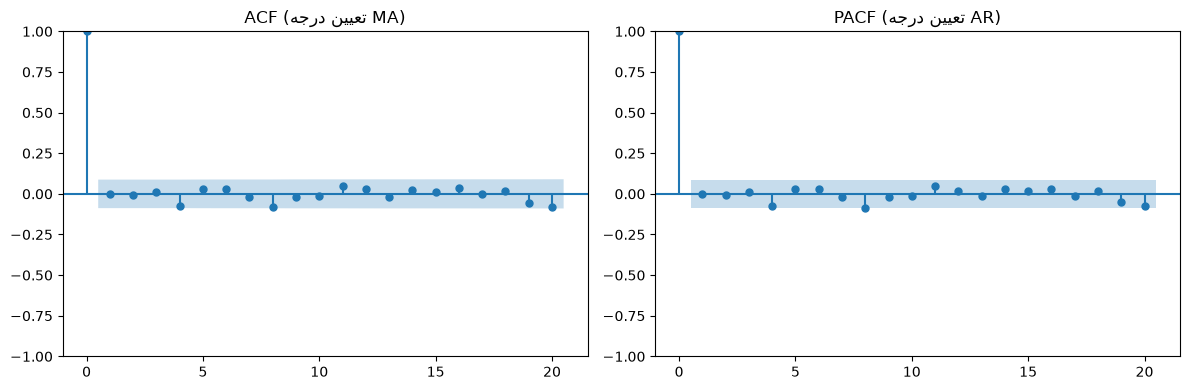

In [7]:
fig, axes = plt.subplots(1,2,figsize=(12,4))

# نمودار خودهمبستگی (ACF) برای تشخیص درجه MA (q)
plot_acf(returns, lags=20, ax=axes[0], title="ACF (تعیین درجه MA)")

# نمودار خودهمبستگی جزئی (PACF) برای تشخیص درجه AR (p)
plot_pacf(returns, lags=20, ax=axes[1], title="PACF (تعیین درجه AR)")

plt.tight_layout()
plt.show()

#### Step4: پیش‌بینی روند و میانگین با مدل ARIMA

In [8]:
arima_order = (1,0,1)
# انتخاب درجه فرضی (p=1, d=0, q=1) بر اساس سری زمانی ایستا شده
arima_model = ARIMA(returns, order=arima_order)
arima_results = arima_model.fit()

##### استخراج باقی‌مانده‌ها(Residuals)

In [9]:
residuals = arima_results.resid

In [10]:
print("--- خلاصه پیش‌بینی میانگین (ARIMA) ---")
print(f"ضریب AR(1): {arima_results.params.get('ar.L1', 0):.4f}")
print(f"ضریب MA(1): {arima_results.params.get('ma.L1', 0):.4f}\n")

--- خلاصه پیش‌بینی میانگین (ARIMA) ---
ضریب AR(1): -0.8541
ضریب MA(1): 0.8763



#### Step5: بررسی ریسک و نوسانات با مدل GARCH

In [11]:
garch_model = arch_model(residuals, mean='Zero', vol='GARCH', p=1, q=1)
garch_results = garch_model.fit(disp='off')

##### استخراج نوسان‌پذیری مشروط (Conditional Volatility / Risk)

In [12]:
df.loc[returns.index, 'volatility'] = garch_results.conditional_volatility

#### پیش‌بینی ۱ گام به جلو (برای روز کاری بعدی)

In [13]:
next_return_pred = arima_results.forecast(steps=1).iloc[0]
next_vol_pred = np.sqrt(garch_results.forecast(horizon=1).variance.iloc[-1,0])

In [14]:
print("--- خروجی نهایی مدل ترکیبی ARIMA-GARCH ---")
print(f"پیش‌بینی بازدهی فردا (میانگین ARIMA): {next_return_pred:.4f}%")
print(f"پیش‌بینی ریسک/نوسان فردا (واریانس GARCH): {next_vol_pred:.4f}%\n")

--- خروجی نهایی مدل ترکیبی ARIMA-GARCH ---
پیش‌بینی بازدهی فردا (میانگین ARIMA): 0.0229%
پیش‌بینی ریسک/نوسان فردا (واریانس GARCH): 2.0689%



##### رسم نمودار نوسان‌پذیری و خوشه‌ای شدن ریسک

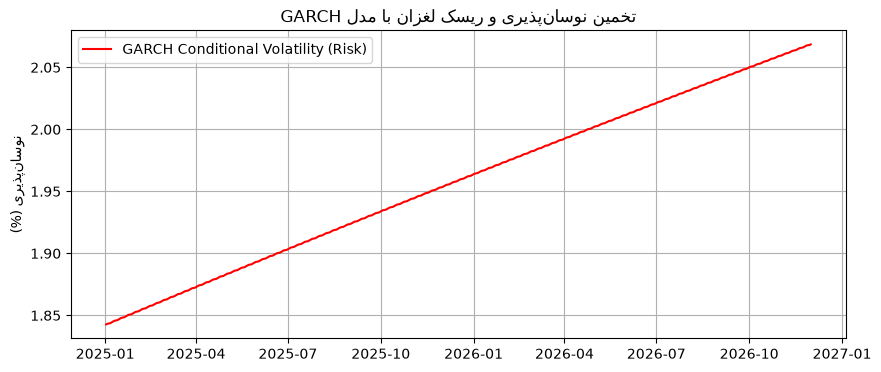

In [15]:
plt.figure(figsize=(10, 4))
plt.plot(df['volatility'], color='red', label='GARCH Conditional Volatility (Risk)')
plt.title('تخمین نوسان‌پذیری و ریسک لغزان با مدل GARCH')
plt.ylabel('نوسان‌پذیری (%)')
plt.grid(True)
plt.legend()
plt.show()